<a href="https://colab.research.google.com/github/jbraga100404-hue/ntu/blob/main/2.1_Ocean_Colour_with_PACE_OCI/2.1.1_PACE_OCI_Chlorophyll_a_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 2.1 — Ocean Colour and Sea Surface Temperature

Phytoplankton are microscopic plants in the sunlit surface of the ocean. They sit at the bottom of almost every marine food chain and draw a large amount of carbon out of the atmosphere. We cannot see them individually from space, but they change the colour of the water.

This notebook maps **chlorophyll-a**, the green pigment they photosynthesise with, and **particulate organic carbon (POC)**, the carbon held in particles, both from PACE. It then adds **sea surface temperature** from Himawari-9 and reads the three together.

**The plan:** PACE data (§2–3) → map chlorophyll-a (§4) → optional experiments (§5–7) → sea surface temperature (§8) → all three together (§9).

**Assignment questions 1, 2 and 3 come from this notebook.** Question 1 uses the figure and table in §8. Questions 2 and 3 use §9. Sections 5 and 7 are optional and not marked.

**Accounts you need:** [NASA Earthdata](https://urs.earthdata.nasa.gov/users/new) for the ocean colour, and [JAXA P-Tree](https://www.eorc.jaxa.jp/ptree/) for the temperature in §8.

## Setting up

Run the cell below first, before anything else on this page.

Colab hands you a completely empty machine, so this cell installs the packages the tutorial needs, creates the folders the notebook writes into, and sets up `login()`, which the download cells use to get your data provider username and password out of your Colab Secrets.

Colab forgets everything between sessions, so run it again whenever you reopen the notebook.

In [1]:
# --- Setup: run this cell first. Safe to re-run. ---------------------------
# Colab gives you an empty machine and takes it back when the session ends,
# so this installs the packages the tutorial needs, and sets up how the
# download cells get your data provider logins. Run it again whenever you
# reopen the notebook.

import importlib
import importlib.util
import os
import subprocess
import sys

try:
    import google.colab               # noqa: F401 - importing it is the test
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REQUIRED = {                      # import name -> pip name
    "cartopy": "cartopy",
    "earthaccess": "earthaccess>=0.16",
    "h5netcdf": "h5netcdf",
    "matplotlib": "matplotlib",
    "netCDF4": "netCDF4",
    "xarray": "xarray",
}

missing = [spec for mod, spec in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]

if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                   check=False)
    importlib.invalidate_caches()

    # Check they import, rather than that pip said it was fine: a package can
    # install cleanly and still fail to load, and the fix for that is a
    # restart, which pip cannot do for you.
    broken = []
    for mod in REQUIRED:
        try:
            importlib.import_module(mod)
        except Exception as error:        # noqa: BLE001 - report anything
            broken.append(f"{mod} ({type(error).__name__}: {error})")

    if broken:
        print("\nInstalled, but these still will not import:")
        for line in broken:
            print("   ", line)
        print("Runtime -> Restart session, then run this cell again.")
    else:
        print("Ready.")
else:
    print("Ready - nothing to install.")

# --- Signing in ------------------------------------------------------------
# This defines `login()`. The download cells below call it when they need your
# username and password for a data provider; nothing is asked for here.
#
# It looks in **Colab Secrets** first - the key icon in the left sidebar. A
# secret belongs to your Google account rather than to this notebook, so you
# add it once and every tutorial in the course finds it. Turn on "Notebook
# access" for each. This tutorial asks for:
#
#     EARTHDATA_USERNAME  and  EARTHDATA_PASSWORD
#         your NASA Earthdata login, for the ocean colour in sections 2-7
#
#     PTREE_USERNAME  and  PTREE_PASSWORD
#         your P-Tree FTP credentials, for the temperature in sections 8-9 -
#         NOT your P-Tree website login
#
# There is no typing them in here instead. A notebook can read Secrets but
# cannot write them, so a password typed into a cell would be gone again next
# session - and saved into the notebook if you shared it. `login()` says what
# to add and where if a secret is missing.

CREDENTIALS = {            # what to call it -> secret names, and sign-up
    "NASA Earthdata":
        ("EARTHDATA_USERNAME", "EARTHDATA_PASSWORD",
         "https://urs.earthdata.nasa.gov/users/new"),
    "JAXA P-Tree":
        ("PTREE_USERNAME", "PTREE_PASSWORD",
         "https://www.eorc.jaxa.jp/ptree/registration_top.html"),
}


def read_secret(name):
    """One Colab secret, or None if unset or not shared with this notebook."""
    if not IN_COLAB:
        return None
    try:
        from google.colab import userdata

        return (userdata.get(name) or "").strip() or None
    except Exception:                 # noqa: BLE001 - unset, or not shared
        return None


def login(provider):
    """The username and password for one data provider, from Colab Secrets.

    Nothing is typed into this notebook. Secrets are re-read on every call, so
    correcting one in the sidebar and running the cell again takes effect.
    """
    user_secret, pass_secret, register = CREDENTIALS[provider]
    user, password = read_secret(user_secret), read_secret(pass_secret)

    if not (user and password):
        raise RuntimeError(
            f"{provider}: {user_secret} and {pass_secret} are not readable.\n\n"
            "Open the key icon in the left sidebar - the Secrets tab - and for\n"
            "each of the two:\n"
            "    1. click + Add new secret\n"
            f"    2. put {user_secret} (then {pass_secret}) in Name\n"
            "    3. paste the value in Value\n"
            "    4. switch Notebook access on\n\n"
            "Then run this cell again. If they are already there, it is the\n"
            "Notebook access switch that is off for this notebook.\n\n"
            f"No account yet? Register at {register}")

    return user, password

Installing: cartopy, earthaccess>=0.16, netCDF4
Ready.


In [2]:
# --- Folders and the figure saver: run this after the setup cell above. ---
# The setup cell installed the packages. This one makes the folders the
# notebook writes into, and defines save_fig(). Safe to re-run.
import os
import warnings

# Downloads go in data/, figures in output/, both beside this notebook.
DATA_DIR = os.path.join(os.getcwd(), "data", "Chlorophyll-a")
FIG_DIR = os.path.join(os.getcwd(), "output", "figures")
for d in (DATA_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# Silence one harmless shapely warning that cartopy triggers on every map.
warnings.filterwarnings(
    "ignore", category=RuntimeWarning,
    message="invalid value encountered in create_collection")

# Turn off Jupyter's tight crop, which mangles cartopy maps into thin strips.
try:
    _shell = get_ipython()
except NameError:                      # not running under IPython
    _shell = None
if _shell is not None:
    _shell.run_line_magic(
        "config", "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")

# cartopy puts a title at an infinite y when an axes has labelled gridlines, so
# the title falls off the canvas and out of the saved PNG. Pin it to the top of
# the axes instead; harmless on ordinary plots.
import matplotlib as mpl

mpl.rcParams["axes.titley"] = 1.0
mpl.rcParams["axes.titlepad"] = 6


def save_fig(fig, name, dpi=200):
    """Write a figure to output/figures/ so you can put it in your Word document.

    On Colab, open the folder icon in the left sidebar, find the file, and
    use its three-dot menu to Download it. The runtime is thrown away when
    the session ends, so download what you need before you close the tab.
    """
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi)
    print("Saved figure:", os.path.relpath(path, os.getcwd()))
    return path

print("Data will be downloaded to:", DATA_DIR)
print("Figures will be saved to  :", FIG_DIR)

Data will be downloaded to: /content/data/Chlorophyll-a
Figures will be saved to  : /content/output/figures


## 1. What are we actually measuring?

Chlorophyll-a absorbs **blue** light strongly (around 443 nm) and **green** hardly at all (around 555 nm). The more phytoplankton in the water, the less blue comes back out, so the **blue-to-green ratio** of the light leaving the sea drops. PACE measures that ratio, and an algorithm turns it into a concentration in mg m⁻³.

Two limitations:

- **Clouds leave gaps.** The satellite cannot see the sea surface through cloud, which is why we use the *monthly* product.
- **Coastal values are less trustworthy.** Sediment and dissolved organic matter also colour the water, so in a river plume some of what the algorithm calls chlorophyll is really mud.

We use the **Level-3 mapped monthly ocean biogeochemistry** product from OCI, at 0.1°. One file holds four variables:

| Variable | What it is | Units |
|---|---|---|
| `chlor_a` | Chlorophyll-a, a proxy for how much phytoplankton there is | mg m⁻³ |
| `poc` | Particulate organic carbon, living phytoplankton *plus* detritus | mg m⁻³ |
| `carbon_phyto` | Phytoplankton carbon, just the living part | mg m⁻³ |
| `pic` | Particulate inorganic carbon, mostly coccolithophore shells | mol m⁻³ |

Questions 1–3 need POC as well as chlorophyll-a. **Both are in this same file.**

## 2. Downloading the data

`earthaccess` searches the NASA archive and downloads from inside the notebook, reading your Earthdata credentials from the `~/.netrc` file you made in [0.2.1 Account Check](https://github.com/earthobservatory/eyes-on-earth-tutorials-public/blob/main/0.2_Data_Access_Accounts/0.2.1_Account_Check.ipynb). These cells fail without it.

The first cell searches, the second downloads. Check the search found six granules before running the second.

In [3]:
import os

import earthaccess

# earthaccess.login() takes a strategy and nothing else - there is no way
# to hand it a username and password - so the two it reads from the
# environment are set here from your Colab Secrets. Naming the strategy
# matters: the default, "all", falls back to a prompt of its own, and
# that one is easy to miss in a long notebook.
os.environ["EARTHDATA_USERNAME"], os.environ["EARTHDATA_PASSWORD"] = \
    login("NASA Earthdata")

auth = earthaccess.login(strategy="environment")

results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_BGC",     # PACE OCI Level-3 Global Mapped Biogeochemistry
    version="3.2",
    temporal=("2024-11-01", "2025-04-30"),
    granule_name="*MO*0p1*",           # Monthly (MO) files at 0.1 degree
)

print(f"Found {len(results)} granules")      # expect 6, one per month
for r in results[:12]:
    print(" ", r.data_links()[0].split("/")[-1])

Found 6 granules
  PACE_OCI.20241101_20241130.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20241201_20241231.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250101_20250131.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250201_20250228.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250301_20250331.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250401_20250430.L3m.MO.BGC.V3_2.0p1deg.nc


In [4]:
# Download them.
files = earthaccess.download(results, DATA_DIR)
print(f"\nDownloaded {len(files)} files to {DATA_DIR}")

QUEUEING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/6 [00:00<?, ?it/s]


Downloaded 6 files to /content/data/Chlorophyll-a


## 3. Look inside the file

Three cells: the first lists the files into `paths`, which every later section reads from, the second opens one and prints everything in it, the third pulls out what we need.

**Look for** the four variables, `poc` included, the **units** of each, and the **lat/lon bounds**.

In [5]:
import glob

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
print(f"{len(paths)} NetCDF files ready:")
for p in paths:
    print(" ", os.path.basename(p))

6 NetCDF files ready:
  PACE_OCI.20241101_20241130.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20241201_20241231.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250101_20250131.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250201_20250228.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250301_20250331.L3m.MO.BGC.V3_2.0p1deg.nc
  PACE_OCI.20250401_20250430.L3m.MO.BGC.V3_2.0p1deg.nc


In [6]:
import xarray as xr

ds = xr.open_dataset(paths[0])
ds

<xarray.Dataset> Size: 104MB
Dimensions:       (lat: 1800, lon: 3600)
Coordinates:
  * lat           (lat) float32 7kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon           (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Data variables:
    poc           (lat, lon) float32 26MB ...
    pic           (lat, lon) float32 26MB ...
    chlor_a       (lat, lon) float32 26MB ...
    carbon_phyto  (lat, lon) float32 26MB ...
Attributes: (12/55)
    product_name:                      PACE_OCI.20241101_20241130.L3m.MO.BGC....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    id:                                L3/PACE_OCI.20241101_20241130.L3m.MO.B...
    history:                           /sdps/sdpsoper/Science/OCSSW/V2026.2/b...
    processing_version:                3.2
    identifier_product_doi_authority:  https://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/OC_BGC/3.2

In [7]:
# Every variable in the file, with its units. Questions 1-3 of the assignment need
# poc as well as chlor_a, and here it is - same grid, same months.
for name, da in ds.data_vars.items():
    print(f"{name:14s} {str(da.attrs.get('units', '?')):10s} {da.attrs.get('long_name', '')}")

# The variable we start with, and its metadata.
chl = ds["chlor_a"]
print("\nUnits         :", chl.attrs.get("units"))
print("Valid range   :", chl.attrs.get("valid_min"), "to", chl.attrs.get("valid_max"))
print("Lat range     :", float(ds.lat.min()), "to", float(ds.lat.max()))
print("Lon range     :", float(ds.lon.min()), "to", float(ds.lon.max()))
print("Grid shape    :", chl.shape)

poc            mg m^-3    Particulate Organic Carbon, D. Stramski, 2022 (hybrid version)
pic            mol m^-3   Calcite Concentration, CI2 algorithm, C. Mitchell et al., 2017
chlor_a        mg m^-3    Chlorophyll Concentration, OCI Algorithm
carbon_phyto   mg m^-3    Phytoplankton Carbon

Units         : mg m^-3
Valid range   : 0.001 to 100.0
Lat range     : -89.95000457763672 to 89.94999694824219
Lon range     : -179.9499969482422 to 179.95001220703125
Grid shape    : (1800, 3600)


> `xarray` keeps `lat` and `lon` attached to the array, so `sel(lon=slice(90, 140))` means "the piece between 90°E and 140°E".

## 4. Our first map

Chlorophyll-a across the whole world.

**The colour scale is logarithmic.** Chlorophyll-a spans a factor of a thousand, from about 0.01 mg m⁻³ in a gyre to over 10 mg m⁻³ in coastal water. Spread colours evenly across that and almost the whole ocean comes out the same dark blue: on a linear scale from 0 to 20 mg m⁻³, a tenfold rise from 0.05 to 0.5 mg m⁻³ uses about 2% of the colour bar. A log scale gives equal space to equal *multiplications* instead, so 0.1 → 1 and 1 → 10 get the same amount of bar. That suits chlorophyll-a, which is spread out in a **log-normal** way.

Grid: 1800 x 3600 = 6.5 million cells


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved figure: output/figures/chlor_a_global.png


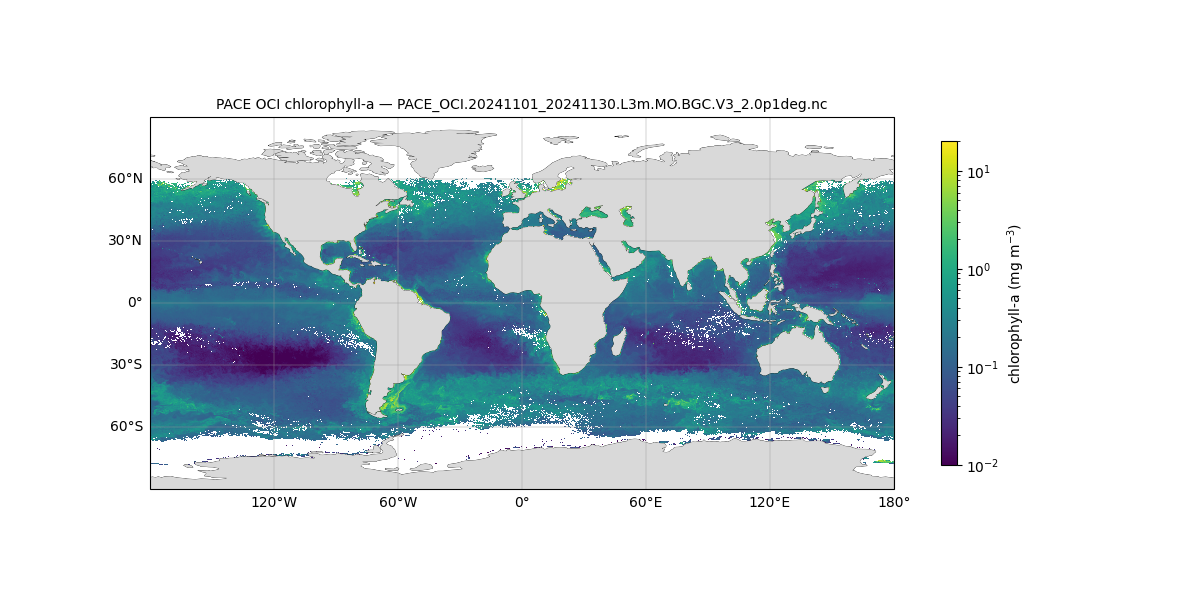

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

chl = ds["chlor_a"]
print(f"Grid: {chl.shape[0]} x {chl.shape[1]} = {chl.size / 1e6:.1f} million cells")


def image_extent(da, x="lon", y="lat"):
    """Extent and origin for imshow: the outer edges of a cell-centred grid."""
    dx = abs(float(da[x][1] - da[x][0]))
    dy = abs(float(da[y][1] - da[y][0]))
    extent = [float(da[x].min()) - dx / 2, float(da[x].max()) + dx / 2,
              float(da[y].min()) - dy / 2, float(da[y].max()) + dy / 2]
    # Clamp to the globe: an edge past 180 makes cartopy draw the whole world.
    extent = [max(extent[0], -180.0), min(extent[1], 180.0),
              max(extent[2], -90.0), min(extent[3], 90.0)]
    # Round off floating-point noise in the coordinates.
    extent = [round(v, 6) for v in extent]
    origin = "upper" if float(da[y][0]) > float(da[y][-1]) else "lower"
    return extent, origin

extent, origin = image_extent(chl)

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})
# NaN cells are drawn transparent, so gaps show the background through.
im = ax.imshow(
    chl.values, extent=extent, origin=origin,
    transform=ccrs.PlateCarree(), interpolation="nearest",
    norm=LogNorm(vmin=0.01, vmax=20), cmap="viridis",
)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
gl.top_labels = gl.right_labels = False
ax.set_title(f"PACE OCI chlorophyll-a — {os.path.basename(paths[0])}", fontsize=10)
fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.7,
             label="chlorophyll-a (mg m$^{-3}$)")

save_fig(fig, "chlor_a_global")
plt.show()

### A short detour: tools the rest of the notebook uses

The cell sets up `REGIONS` (named boxes, each `(west, east, south, north)` in degrees), `select_region()`, which cuts a variable down to one of them, and `month_label()` / `month_key()`, which turn a filename into something like `Nov 2024`.

Nothing is plotted, but read the region names: you choose from them in a moment.

In [9]:
from datetime import datetime

import numpy as np

# Named regions as (lon_west, lon_east, lat_south, lat_north), in degrees.
# Add your own - any box works, as long as it is inside -180..180 and -90..90.
REGIONS = {
    "Southeast Asia":       (90, 140, -15, 25),
    "South China Sea":      (105, 121, 5, 23),
    "Java Sea":             (105, 118, -9, -3),
    "Bay of Bengal":        (78, 100, 5, 23),
    "Arabian Sea":          (50, 78, 5, 25),
    "Coral Sea":            (142, 165, -25, -8),
    "North Pacific gyre":   (150, 180, 15, 35),
    "Equatorial Pacific":   (-170, -90, -5, 5),
    "Peru upwelling":       (-90, -70, -20, 0),
    "Benguela upwelling":   (5, 20, -35, -15),
}


def select_region(da, box):
    """Cut a (lat, lon) array down to a box, whichever way lat is ordered."""
    west, east, south, north = box
    lat_descending = float(da.lat[0]) > float(da.lat[-1])
    lat_slice = slice(north, south) if lat_descending else slice(south, north)
    return da.sel(lon=slice(west, east), lat=lat_slice)


def month_key(nc_path):
    """'PACE_OCI.20241101_20241130.L3m...' -> '202411'."""
    return os.path.basename(nc_path).split(".")[1].split("_")[0][:6]


def month_label(nc_path):
    """'PACE_OCI.20241101_20241130.L3m...' -> 'Nov 2024'."""
    return datetime.strptime(month_key(nc_path), "%Y%m").strftime("%b %Y")


def slug(name):
    return name.lower().replace(" ", "_")

# Defaults for the region maps in sections 5 and 6. Section 5 lets you change
# REGION and VARIABLE; section 6 uses whatever they are set to, so section 6
# works whether or not you ran the optional section 5.
REGION = "Southeast Asia"
VARIABLE = "chlor_a"

# Sensible log-scale limits for each variable, so one region map is comparable
# with the next one you draw. Edit them if a region saturates.
LIMITS = {
    "chlor_a":      (0.03, 20),     # mg m^-3
    "poc":          (20, 2000),     # mg m^-3
    "carbon_phyto": (3, 300),       # mg m^-3
    "pic":          (1e-5, 1e-2),   # mol m^-3
}

by_month = {month_key(p): p for p in paths}     # "202411" -> its file

print(f"{len(REGIONS)} regions defined; {len(paths)} months loaded: "
      + ", ".join(month_label(p) for p in paths))

10 regions defined; 6 months loaded: Nov 2024, Dec 2024, Jan 2025, Feb 2025, Mar 2025, Apr 2025


## 5. Where is the ocean green, and why? *(optional)*

Phytoplankton need **light** and **nutrients**. Light is everywhere at the surface, so nutrients are the constraint. Warm surface water floats on cold water and resists mixing with it, so nutrients that sink below the sunlit layer stay out of reach.

The green parts of the ocean are therefore where **something brings deep water up, or feeds nutrients in from the side**:

- **Upwelling coasts**, Peru, Benguela, the Arabian Sea in the southwest monsoon. Wind pushes surface water offshore and deep water rises to replace it.
- **The equator**, where the trades push surface water away on both sides and cold, nutrient-rich water rises between. This is the "cold tongue" you meet again in 2.2 and 2.3.
- **Shelf seas and river mouths**, the Java Sea, the Bay of Bengal. Shallow enough for tides to stir the whole column, and fed from the land.

The **subtropical gyres** are the opposite: warm, stably layered, cut off from below. They are the deserts of the ocean.

### Settings you can change

`REGION` picks one of the named boxes, `VARIABLE` picks which variable to map. Both already have a default from section 4, so this cell is changing them rather than setting them for the first time. Run the cell for an upwelling region and for a gyre, then switch `VARIABLE` to `poc` and see whether the pattern holds.

Southeast Asia, chlor_a, Nov 2024
  valid pixels        : 152,934 of 200,000 (76%)
  median              : 0.115 mg m^-3
  10th-90th percentile: 0.0349 to 0.455 mg m^-3  (a factor of 13)
  above 1 mg m^-3 : 6% of the box


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved figure: output/figures/chlor_a_region_southeast_asia.png


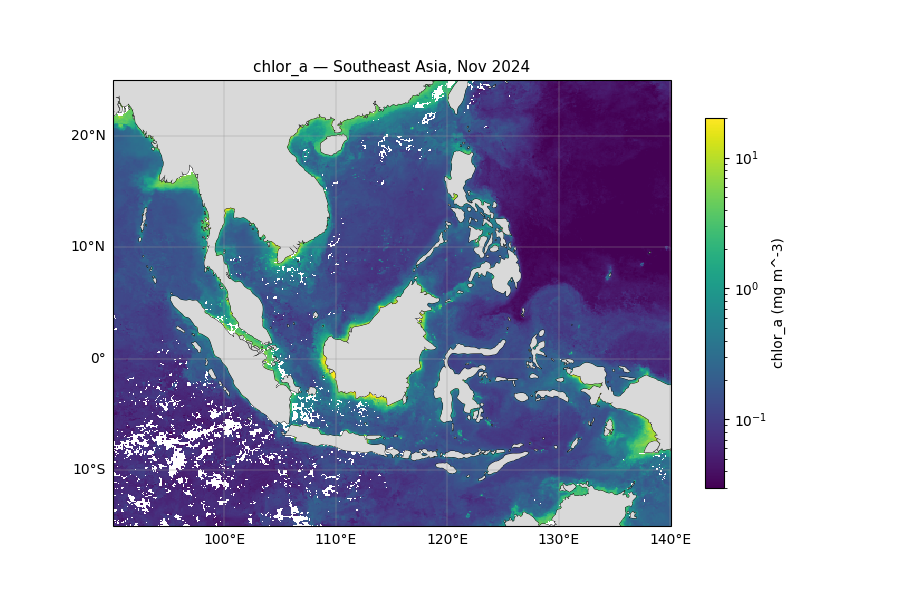

In [10]:
import numpy as np

# ── Try changing these ────────────────────────────────────────────────────
# The region names you can use, copy one exactly (section 4 defines the boxes):
#
#   "Southeast Asia"       "South China Sea"      "Java Sea"
#   "Bay of Bengal"        "Arabian Sea"          "Coral Sea"
#   "North Pacific gyre"   "Equatorial Pacific"   "Peru upwelling"
#   "Benguela upwelling"
#
REGION = "Southeast Asia"       # or add your own box in section 4
VARIABLE = "chlor_a"            # "chlor_a", "poc", "carbon_phyto" or "pic"
# ─────────────────────────────────────────────────────────────────────────

PRODUCTIVE = {"chlor_a": 1.0, "poc": 100.0, "carbon_phyto": 30.0, "pic": 1e-3}

da = select_region(ds[VARIABLE], REGIONS[REGION])
units = ds[VARIABLE].attrs.get("units", "")
values = da.values[np.isfinite(da.values)]
if values.size == 0:
    raise ValueError(f"No valid {VARIABLE} pixels in {REGION} - check the box in REGIONS.")

vmin, vmax = LIMITS[VARIABLE]
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(da.lon, da.lat, da, transform=ccrs.PlateCarree(),
                   norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis", shading="auto")
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
gl.top_labels = gl.right_labels = False
ax.set_title(f"{VARIABLE} — {REGION}, {month_label(paths[0])}", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label=f"{VARIABLE} ({units})")

p10, p50, p90 = np.percentile(values, [10, 50, 90])
print(f"{REGION}, {VARIABLE}, {month_label(paths[0])}")
print(f"  valid pixels        : {values.size:,} of {da.size:,} ({100 * values.size / da.size:.0f}%)")
print(f"  median              : {p50:.3g} {units}")
print(f"  10th-90th percentile: {p10:.3g} to {p90:.3g} {units}  (a factor of {p90 / p10:.0f})")
print(f"  above {PRODUCTIVE[VARIABLE]:g} {units:8s}: {100 * np.mean(values > PRODUCTIVE[VARIABLE]):.0f}% of the box")

save_fig(fig, f"{VARIABLE}_region_{slug(REGION)}")
plt.show()

## 6. Putting all the months on one figure

One panel per month, all on the same log colour scale, so you are comparing concentrations rather than colour ramps. The cell uses whatever `REGION` and `VARIABLE` are currently set to. Section 4 gives them a default, so this cell runs on its own; if you did run section 5, it uses the region you chose there.

Saved figure: output/figures/chlor_a_monthly_panels_southeast_asia.png


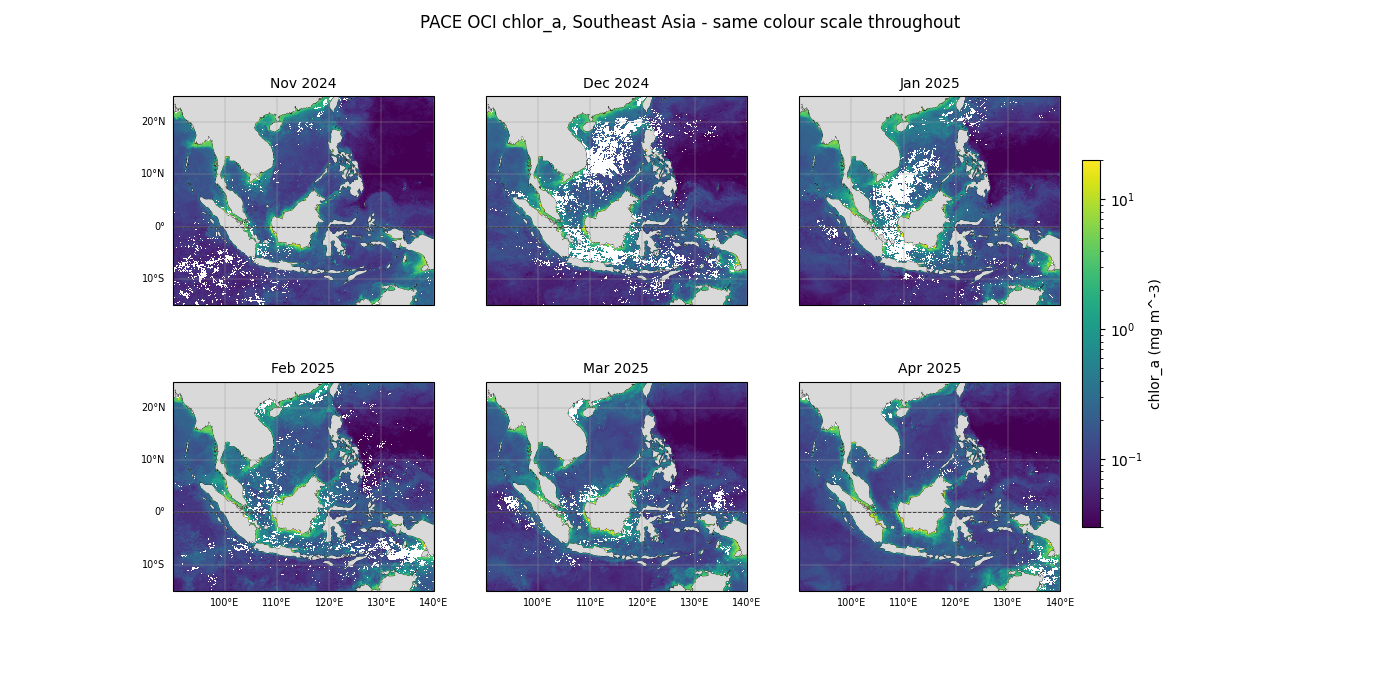

In [11]:
import math

if not paths:
    raise RuntimeError("No .nc files found - run the download cells in section 2 first.")

vmin, vmax = LIMITS[VARIABLE]
ncols = 3
nrows = math.ceil(len(paths) / ncols)

# squeeze=False keeps `axes` a 2-D array however many panels there are.
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.4 * nrows),
                         subplot_kw={"projection": ccrs.PlateCarree()},
                         squeeze=False)
axes = axes.ravel()

for ax, path in zip(axes, paths):
    with xr.open_dataset(path) as d:
        panel = select_region(d[VARIABLE], REGIONS[REGION])
        # One norm and one cmap for every panel - that is what makes the
        # months comparable.
        im = ax.pcolormesh(panel.lon, panel.lat, panel, transform=ccrs.PlateCarree(),
                           norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis",
                           shading="auto")
    ax.coastlines(linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    # Labelled gridlines on the outer panels, so you can tell where the
    # equator is - the assignment asks you to compare north of it with south.
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
    gl.top_labels = gl.right_labels = False
    gl.left_labels = axes.tolist().index(ax) % ncols == 0
    gl.bottom_labels = axes.tolist().index(ax) >= len(paths) - ncols
    gl.xlabel_style = gl.ylabel_style = {"size": 7}
    _w, _e, _s, _n = REGIONS[REGION]
    if _s < 0 < _n:                      # draw the equator itself
        ax.plot([_w, _e], [0, 0], transform=ccrs.PlateCarree(),
                color="0.25", linewidth=0.7, linestyle="--", zorder=3)
    ax.set_title(month_label(path), fontsize=10)

for ax in axes[len(paths):]:       # blank out any unused panels
    ax.axis("off")

fig.colorbar(im, ax=axes.tolist(), shrink=0.7, pad=0.02,
             label=f"{VARIABLE} ({ds[VARIABLE].attrs.get('units', '')})")
fig.suptitle(f"PACE OCI {VARIABLE}, {REGION} - same colour scale throughout")

save_fig(fig, f"{VARIABLE}_monthly_panels_{slug(REGION)}")
plt.show()

## 7. The seasonal cycle as a number *(optional)*

Six maps side by side show you *that* something changes. A time series shows **how much**, and **when**.

Over Southeast Asia the driver is the **monsoon**. From November to March the northeast monsoon blows cool, dry air down the South China Sea: the wind stirs the surface layer deeper and the cooling makes the column less stably layered, so it mixes more easily. The result is a **winter bloom**. South of the equator the seasons reverse, the Java Sea gets its strongest winds in the southeast monsoon, June to September. The Arabian Sea has **two** blooms a year: a smaller winter one from convective mixing, and a bigger summer one from upwelling off Oman.

### Settings you can change

- `COMPARE`, the list of regions to plot. Drop any that clutter the figure, or add one of your own from section 4.
- `STATISTIC`, how each month is reduced to a single number.
- `TS_VARIABLE`, which variable to track.

Afterwards, switch `STATISTIC` from `"median"` to `"mean"` and watch the curves move. The mean gets dragged upward by a handful of very high coastal pixels; the median stays where most of the water actually is. That is why we default to the median.

### 🔍 What to notice

Which month each region peaks in, and whether regions on opposite sides of the equator move in opposite directions. The y-axis is logarithmic, so equal vertical distances are equal **factors**, not equal amounts.

median chlor_a:
                        Nov 2024  Dec 2024  Jan 2025  Feb 2025  Mar 2025  Apr 2025
South China Sea            0.148     0.198     0.282     0.222     0.171     0.121   peak: Jan 2025
Java Sea                   0.212     0.414     0.335     0.336     0.295     0.272   peak: Dec 2024
Arabian Sea                0.236     0.348      0.35     0.338     0.194     0.155   peak: Jan 2025
North Pacific gyre        0.0346    0.0404    0.0468    0.0526    0.0545    0.0458   peak: Mar 2025
Equatorial Pacific         0.151      0.16     0.153     0.148     0.147     0.152   peak: Dec 2024
Peru upwelling             0.237     0.245     0.248     0.226     0.208     0.225   peak: Jan 2025
Saved figure: output/figures/chlor_a_timeseries_median.png


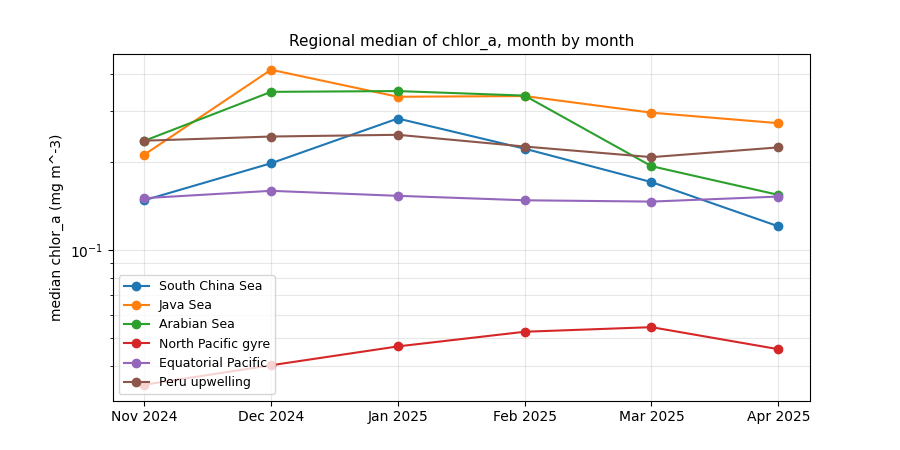

In [12]:
# ── Try changing these ────────────────────────────────────────────────────
COMPARE = ["South China Sea", "Java Sea", "Arabian Sea", "North Pacific gyre",
           "Equatorial Pacific", "Peru upwelling"]
STATISTIC = "median"          # "median" or "mean"
TS_VARIABLE = "chlor_a"       # any of the four variables
# ─────────────────────────────────────────────────────────────────────────

reducer = {"median": np.nanmedian, "mean": np.nanmean}[STATISTIC]
labels = [month_label(p) for p in paths]
series = {}

for region in COMPARE:
    box = REGIONS[region]
    series[region] = []
    for path in paths:
        with xr.open_dataset(path) as d:
            series[region].append(reducer(select_region(d[TS_VARIABLE], box).values))

fig, ax = plt.subplots(figsize=(9, 4.5))
for region, ys in series.items():
    ax.plot(labels, ys, marker="o", linewidth=1.5, label=region)
ax.set_yscale("log")
ax.set_ylabel(f"{STATISTIC} {TS_VARIABLE} ({ds[TS_VARIABLE].attrs.get('units', '')})")
ax.set_title(f"Regional {STATISTIC} of {TS_VARIABLE}, month by month", fontsize=11)
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)

# The same numbers as a table, for your assignment.
print(f"{STATISTIC} {TS_VARIABLE}:")
print(" " * 22 + "".join(f"{lab:>10s}" for lab in labels))
for region, ys in series.items():
    peak = labels[int(np.nanargmax(ys))]
    print(f"{region:22s}" + "".join(f"{y:10.3g}" for y in ys) + f"   peak: {peak}")

save_fig(fig, f"{TS_VARIABLE}_timeseries_{STATISTIC}")
plt.show()

### Optional — mapping the change between two months

To show *where* chlorophyll-a changed rather than just when, compare two months pixel by pixel. Not by subtracting: a change of 0.5 mg m⁻³ is a catastrophe in the open ocean and invisible at the coast, so a difference map is dominated by the coast.

The fair comparison is the **ratio**. We plot `log10(A / B)` on a diverging scale centred on zero, so `+0.3` means A is about **twice** B, `0` means no change, and `−0.3` about **half**.

Southeast Asia: 16% of pixels at least doubled, 4% at least halved, median change a factor of 1.20
Saved figure: output/figures/chlor_a_ratio_202501_over_202411_southeast_asia.png


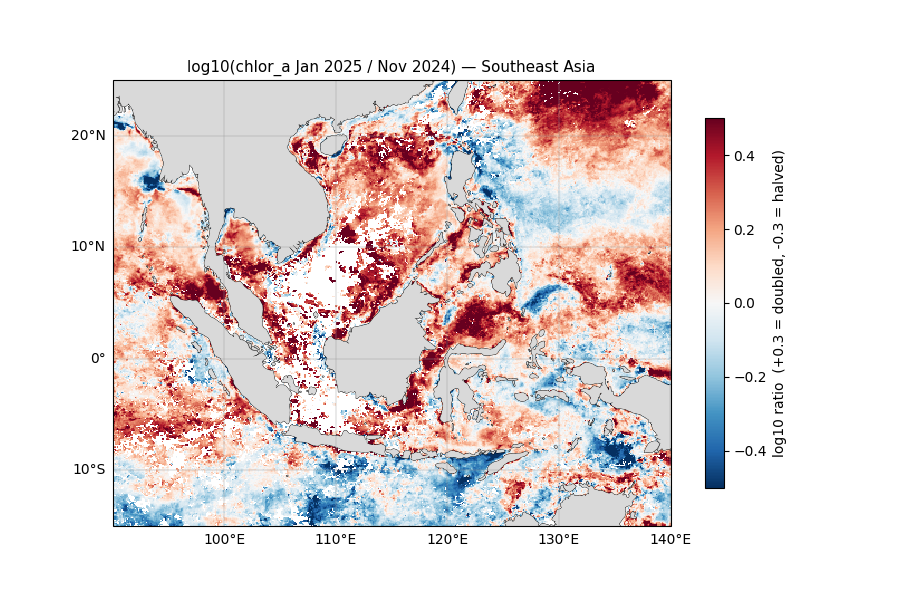

In [13]:
# ── Try changing these ────────────────────────────────────────────────────
MONTH_A, MONTH_B = "202501", "202411"    # YYYYMM keys of two files you have
RATIO_VARIABLE = "chlor_a"
RATIO_LIM = 0.5                          # log10 units: 0.5 is a factor of about 3
# ─────────────────────────────────────────────────────────────────────────

for key in (MONTH_A, MONTH_B):
    if key not in by_month:
        raise KeyError(f"No file for {key}. You have: {', '.join(sorted(by_month))}")

with xr.open_dataset(by_month[MONTH_A]) as d:
    a = select_region(d[RATIO_VARIABLE], REGIONS[REGION]).load()
with xr.open_dataset(by_month[MONTH_B]) as d:
    b = select_region(d[RATIO_VARIABLE], REGIONS[REGION]).load()

ratio = np.log10(a / b)          # NaN wherever either month has no data

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(ratio.lon, ratio.lat, ratio, transform=ccrs.PlateCarree(),
                   cmap="RdBu_r", vmin=-RATIO_LIM, vmax=RATIO_LIM, shading="auto")
ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
gl.top_labels = gl.right_labels = False
ax.set_title(f"log10({RATIO_VARIABLE} {month_label(by_month[MONTH_A])} / "
             f"{month_label(by_month[MONTH_B])}) — {REGION}", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label="log10 ratio  (+0.3 = doubled, -0.3 = halved)")

r = ratio.values[np.isfinite(ratio.values)]
print(f"{REGION}: {100 * np.mean(r > 0.3):.0f}% of pixels at least doubled, "
      f"{100 * np.mean(r < -0.3):.0f}% at least halved, "
      f"median change a factor of {10 ** np.median(r):.2f}")

save_fig(fig, f"{RATIO_VARIABLE}_ratio_{MONTH_A}_over_{MONTH_B}_{slug(REGION)}")
plt.show()

## 8. Sea surface temperature, from a second satellite

Questions 1 to 3 ask how temperature, chlorophyll-a and POC fit together, and PACE cannot measure temperature. So this section brings in a second satellite.

Himawari-9 is **geostationary**: it sits over the equator at 140.7°E and turns with the Earth, so it photographs the same face of the planet every ten minutes. PACE, in a polar orbit, passes over a given place once a day at best. The trade is coverage. Himawari sees roughly **80°E to 160°W (200°E)** and nothing outside it, which is why every region in this section is an Asia-Pacific one. It measures in the **thermal infrared**, so it works at night as well as by day. [Notebook 2.2](https://github.com/earthobservatory/eyes-on-earth-tutorials-public/blob/main/2.2_Sea_Surface_Temperature_with_Himawari/) covers the instrument in full.

### What you are downloading

JAXA's monthly Level-3 SST at 0.02°. Four months of 2025, spread through the year, which is what question 1 needs:

`SST_PERIODS = ["202501", "202504", "202507", "202512"]`

Section 9 uses January and April out of those four.

Your P-Tree credentials come from the `~/.netrc` file you made in [0.2.1 Account Check](https://github.com/earthobservatory/eyes-on-earth-tutorials-public/blob/main/0.2_Data_Access_Accounts/0.2.1_Account_Check.ipynb), so you will not be asked for a password.

> Your P-Tree **FTP** credentials are not the same as your P-Tree *website* login.

> ### ⚠️ Colab and FTP do not always get along
>
> JAXA P-Tree is reached over **FTP**, and FTP from a Colab runtime is slower and less reliable than it is from a Codespace. A passive-mode transfer can stall indefinitely rather than failing with an error, which is more annoying than an outright failure.
>
> **If the download hangs**, interrupt the cell and run it again. Files that arrived are kept, so it picks up where it stopped.
>
> **Where your password comes from.** The setup cell at the top defined `login()`, which reads `PTREE_USERNAME` and `PTREE_PASSWORD` from your Colab Secrets and says what to add if either is missing. Your P-Tree **FTP** credentials are not the same as your P-Tree *website* login.

In [14]:
from ftplib import FTP, error_perm

import numpy as np

# ── Try changing these ────────────────────────────────────────────────────
# Four months of 2025, spread through the year. Question 1 needs all four;
# section 9 uses January and April.
SST_PERIODS = ["202501", "202504", "202507", "202512"]
SATELLITE = "H09"                  # H08 for Himawari-8, H09 for Himawari-9
# ─────────────────────────────────────────────────────────────────────────

# The SST files get their own folder, beside the PACE files.
SST_DIR = os.path.join(os.getcwd(), "data", "SST")
os.makedirs(SST_DIR, exist_ok=True)

FTP_SERVER = "ftp.ptree.jaxa.jp"
REMOTE_DIR = "/pub/himawari/L3/SST/v201_nc4_normal_std_monthly/"

# Your PTREE_USERNAME and PTREE_PASSWORD, out of your Colab Secrets - see
# the setup cell at the top.
ftp_user, ftp_password = login("JAXA P-Tree")

# The password is reported as a length rather than printed: a trailing space
# from a paste is invisible otherwise, and is a common cause of a 530 when
# everything looks right.
print(f"user {ftp_user!r} ({len(ftp_user)} chars), "
      f"password {len(ftp_password)} chars")

with FTP(FTP_SERVER) as ftp:
    try:
        ftp.login(ftp_user, ftp_password)
    except error_perm as rejected:
        raise SystemExit(
            f"{rejected}\n\n"
            "P-Tree rejected that login. The three usual causes:\n"
            "  1. It is your P-Tree *website* login. The FTP account is a\n"
            "     separate one, and its username and password are in the\n"
            "     approval email, not on the website.\n"
            "  2. The username is not in the FTP form - usually your email\n"
            "     address with the @ replaced by an underscore, so\n"
            "     you_example.com rather than you@example.com.\n"
            "  3. Your registration has not been approved yet.\n"
        ) from None
    ftp.cwd(REMOTE_DIR)

    for period in SST_PERIODS:
        filename = f"{SATELLITE}_{period}01_0000_1MSST201_FLDK.06001_06001.nc"
        local_path = os.path.join(SST_DIR, filename)

        if os.path.exists(local_path):
            print(f"Already have {filename}")
            continue

        try:
            print(f"Downloading {filename} ...", end=" ", flush=True)
            with open(local_path, "wb") as fh:
                ftp.retrbinary(f"RETR {filename}", fh.write)
            print("done")
        except Exception as err:
            # Report and carry on, so one missing month does not stop the loop.
            if os.path.exists(local_path):
                os.remove(local_path)          # remove the half-written file
            print(f"\n  Error retrieving {filename}: {err}")

# Only the months named in SST_PERIODS, so a file left over from an earlier
# run with different settings cannot turn up in a figure you hand in.
sst_paths = sorted(p for p in glob.glob(os.path.join(SST_DIR, "*.nc"))
                   if os.path.basename(p).split("_")[1][:6] in SST_PERIODS)
print(f"\n{len(sst_paths)} SST file(s) ready in {os.path.relpath(SST_DIR)}")

user 'jbraga100404_gmail.com' (22 chars), password 8 chars

4 SST file(s) ready in data/SST


### Two things to fix before you can map it

**The temperature is in Kelvin.** Subtract 273.15.

**The longitudes are not sorted.** The coordinate starts at 80°E, climbs to just under 180°, then jumps to −180° and runs on to −160°. Written the other way that is 80°E to 200°E, which is outside the −180 to 180 range mapping tools expect. Here we keep only what is west of 180°, which covers the whole Asia-Pacific. Notebook 2.2 needs the part beyond 180° and sorts it out there.

The cell opens the first file, prints what is in it, and does both fixes. **The units and the value range it prints answer Himawari mission question 3.**

In [15]:
sst_var = "sea_surface_temperature"


# SST filenames differ from the PACE ones, so they get their own helpers.
def sst_month_key(nc_path):
    """'H09_20250101_0000_1MSST201_FLDK...' -> '202501'."""
    return os.path.basename(nc_path).split("_")[1][:6]


def sst_month_label(nc_path):
    """'H09_20250101_0000_1MSST201_FLDK...' -> 'Jan 2025'."""
    return datetime.strptime(sst_month_key(nc_path), "%Y%m").strftime("%b %Y")

if not sst_paths:
    raise RuntimeError("No SST files found - run the download cell above first.")

with xr.open_dataset(sst_paths[0]) as sst_ds:
    print("File      :", os.path.basename(sst_paths[0]))
    print("Units     :", sst_ds[sst_var].attrs.get("units"))
    print("Lat range :", float(sst_ds.lat.min()), "to", float(sst_ds.lat.max()))
    # Print the first and last longitude rather than the smallest and largest.
    # min() and max() would hide the problem: this coordinate is not sorted.
    print("Lon starts:", float(sst_ds.lon[0]), "and ends at", float(sst_ds.lon[-1]),
          "  <- not sorted, it wraps past 180")
    # Crop before converting, or 36 million values go into memory first.
    sea = sst_ds[sst_var].squeeze(drop=True).sel(lon=slice(90, 140),
                                                 lat=slice(25, -15)).load()

sea = sea - 273.15                     # Kelvin to Celsius
sea.attrs["units"] = "degrees_Celsius"
print(f"\nSoutheast Asia, {sst_month_label(sst_paths[0])}, after both fixes:")
print(f"  shape       : {sea.shape}")
low, high = np.nanpercentile(sea.values, [2, 98])
print(f"  value range : {float(sea.min()):.1f} to {float(sea.max()):.1f} degrees C")
print(f"  most of it  : {low:.1f} to {high:.1f}  (2nd to 98th percentile - quote "
      "these two for the mission question, the extremes are a handful of bad pixels)")

File      : H09_20250101_0000_1MSST201_FLDK.06001_06001.nc
Units     : kelvin
Lat range : -60.0 to 60.0
Lon starts: 80.0 and ends at -160.0   <- not sorted, it wraps past 180

Southeast Asia, Jan 2025, after both fixes:
  shape       : (2001, 2501)
  value range : 2.4 to 33.5 degrees C
  most of it  : 22.2 to 31.6  (2nd to 98th percentile - quote these two for the mission question, the extremes are a handful of bad pixels)


### The four months on one colour scale

All four panels share one 24 °C to 32 °C scale, for the same reason as section 6.

Underneath, the cell prints the **median SST of two regions** month by month: the South China Sea, a shallow shelf sea, and the North Pacific gyre, open ocean. Those are the two boxes section 9 uses, and question 1 is answered from this figure and this table.

**What moves the temperature: the monsoon.** From November to March the **northeast monsoon** blows cool, dry air off the Asian landmass and down the South China Sea, which cools the surface and stirs the surface layer deeper. From June to September the wind reverses to the warm, humid **southwest monsoon** and the same water warms again. Because the cold air comes off a continent in the north, the swing is large north of the equator and small south of it — the seas around Indonesia stay near 29 °C all year. That asymmetry is what question 1 asks you to describe.

> **The maps are subsampled, the numbers are not.** Each crop is about five million cells, so the drawing takes every nth point. Every number printed comes from the full-resolution array.

Saved figure: output/figures/sst_monthly_panels.png


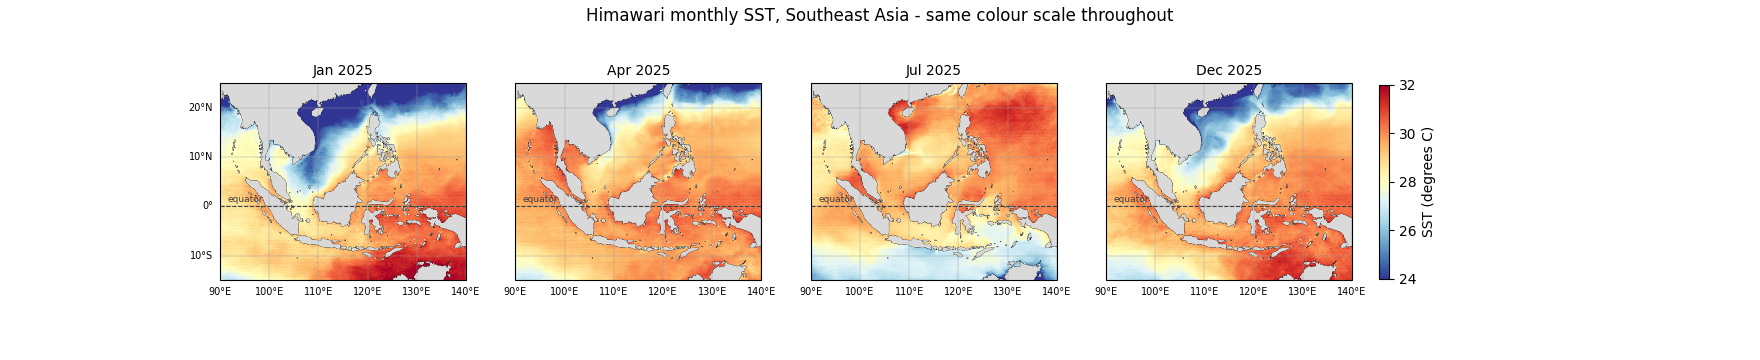

median SST (degrees C)    Jan 2025  Apr 2025  Jul 2025  Dec 2025
South China Sea              25.51     28.61     29.37     26.86
North Pacific gyre           24.86     24.24     28.08     25.31


In [16]:
import math

SEA_LON = slice(90, 140)      # 90E to 140E
SEA_LAT = slice(25, -15)      # 25N to 15S - lat runs north to south in these files

# The two regions question 1 asks you to compare, and the two that section 9
# maps. Same boxes as REGIONS in section 4.
SST_BOXES = ["South China Sea", "North Pacific gyre"]


def for_display(da, max_cells=2_000_000):
    """Subsample a lat/lon grid down to roughly `max_cells`, for drawing only.

    Never use the result for analysis: this takes every nth point, it does not
    average, so extremes shift slightly.
    """
    step = int(np.ceil(np.sqrt(da.size / max_cells)))
    if step <= 1:
        return da
    return da.isel(lat=slice(None, None, step), lon=slice(None, None, step))

ncols = min(4, len(sst_paths))
nrows = math.ceil(len(sst_paths) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.6 * nrows),
                         subplot_kw={"projection": ccrs.PlateCarree()},
                         squeeze=False)
axes = axes.ravel()

for ax, path in zip(axes, sst_paths):
    with xr.open_dataset(path) as d:
        panel = d[sst_var].squeeze(drop=True).sel(lon=SEA_LON, lat=SEA_LAT)
        panel = for_display(panel).load() - 273.15
    # One vmin, one vmax and one colour map for every panel. That is what
    # makes the months comparable.
    im = ax.pcolormesh(panel.lon, panel.lat, panel, transform=ccrs.PlateCarree(),
                       vmin=24, vmax=32, cmap="RdYlBu_r", shading="auto")
    ax.coastlines(linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    # Labelled gridlines plus an explicit equator: question 1 asks whether the
    # seasonal change is bigger north or south of it, so it has to be findable.
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6")
    gl.top_labels = gl.right_labels = False
    gl.left_labels = axes.tolist().index(ax) % ncols == 0
    gl.xlabel_style = gl.ylabel_style = {"size": 7}
    ax.plot([SEA_LON.start, SEA_LON.stop], [0, 0], transform=ccrs.PlateCarree(),
            color="0.25", linewidth=0.8, linestyle="--", zorder=3)
    ax.text(SEA_LON.start + 1.5, 0.8, "equator", transform=ccrs.PlateCarree(),
            fontsize=6.5, color="0.25", zorder=3)
    ax.set_title(sst_month_label(path), fontsize=10)

for ax in axes[len(sst_paths):]:            # blank out any unused panels
    ax.axis("off")

fig.colorbar(im, ax=axes.tolist(), shrink=0.7, pad=0.02, label="SST (degrees C)")
fig.suptitle("Himawari monthly SST, Southeast Asia - same colour scale throughout")
save_fig(fig, "sst_monthly_panels")
plt.show()

# The same data as numbers, at full resolution, for question 1.
print(f"{'median SST (degrees C)':24s}"
      + "".join(f"{sst_month_label(p):>10s}" for p in sst_paths))
for region in SST_BOXES:
    row = []
    for path in sst_paths:
        with xr.open_dataset(path) as d:
            box = select_region(d[sst_var].squeeze(drop=True), REGIONS[region])
            row.append(float(box.median()) - 273.15)
    print(f"{region:24s}" + "".join(f"{value:10.2f}" for value in row))

## 9. Chlorophyll-a, POC and sea surface temperature *(required)*

**Assignment questions 2 and 3 come from this cell.** Run it as it stands.

This section puts all three measurements side by side to ask one question: **how does the temperature of the surface control how much life the water holds?** Warm water is lighter than cold. A warm surface layer floats on the cooler water below and resists mixing with it, and the nutrients are down there. **Warm and calm cuts off the nutrient supply and growth falls. Cool and windy mixes the column, nutrients rise, and phytoplankton bloom.**

### Two kinds of ocean

The two regions this cell maps are not just two places, they are two different kinds of ocean, and **question 3 turns on the difference between them.**

The **South China Sea** is a **shelf sea**: shallow round its edges, ringed by coast and fed by rivers, and stirred hard by the northeast monsoon every winter. Nutrients sit close beneath the surface and something reaches down for them every year, so how much phytoplankton it holds swings widely with the season.

The **North Pacific gyre** is a **subtropical gyre**: the slow, closed circulation that fills the middle of an ocean basin. It is thousands of kilometres from any coast or river, and a deep warm layer floats permanently on the cold water beneath, so the nutrients stay out of reach all year round. Subtropical gyres are the **deserts of the ocean** — permanently low in chlorophyll-a, and permanently short of the nutrients that would change that.

Where deep water *is* brought up the ocean is green instead. That happens at **upwelling** coasts, such as Peru and Benguela, where the wind pushes surface water offshore and deep water rises to replace it, and along the equator, where the trade winds push surface water away on both sides. Section 5 maps those, if you ran it.

Chlorophyll-a and POC are two views of the life that responds. Chlorophyll-a is a **pigment**, so it tracks what is alive and photosynthesising now. POC is a **mass of carbon** in every organic particle: phytoplankton, but also bacteria, zooplankton fragments and detritus. Watch how each of them moves as the temperature changes.

The cell draws **one figure per region**, six panels: chlorophyll-a, POC and SST, in January and in April. Each row shares one colour scale across the two months, so a colour change is a real change. Each figure is scaled to its own region, so colours cannot be compared between regions, and the printed numbers are what you use for that.

Underneath it prints a **table**: the median of each variable per region and month, and the change between the two months.

`COMPARE_REGIONS` and `MONTHS` set the regions and months, and the region names are listed in the cell.

Saved figure: output/figures/chl_poc_sst_south_china_sea_202501_202504.png


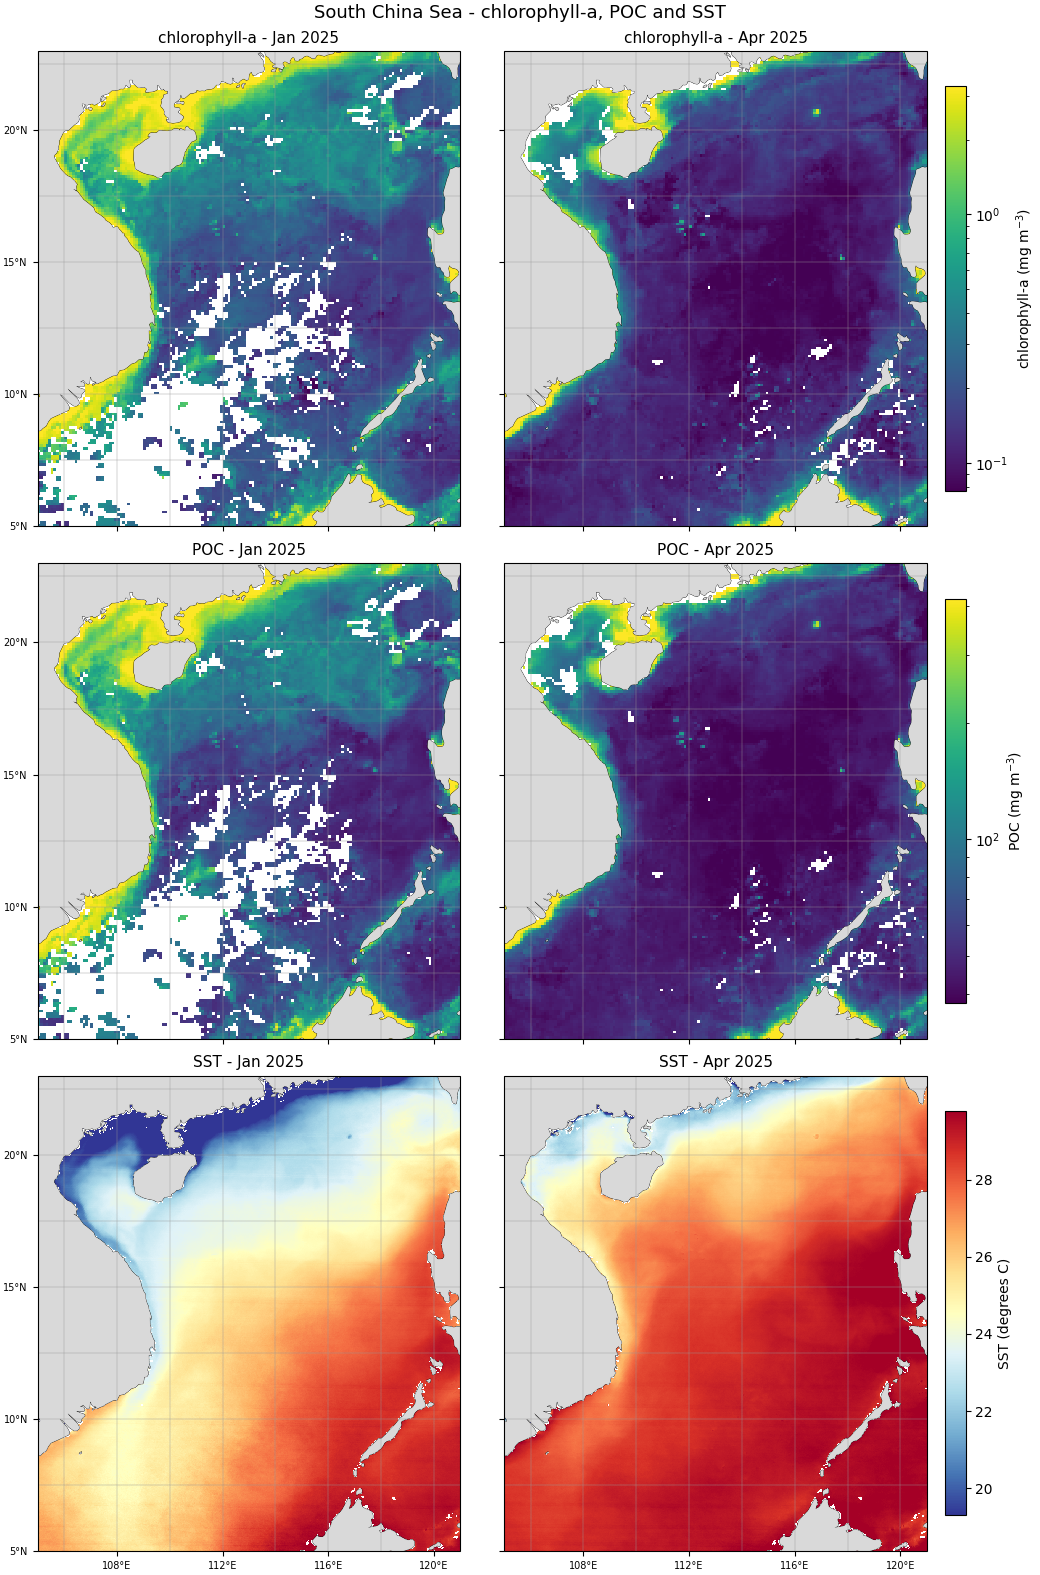

Saved figure: output/figures/chl_poc_sst_north_pacific_gyre_202501_202504.png


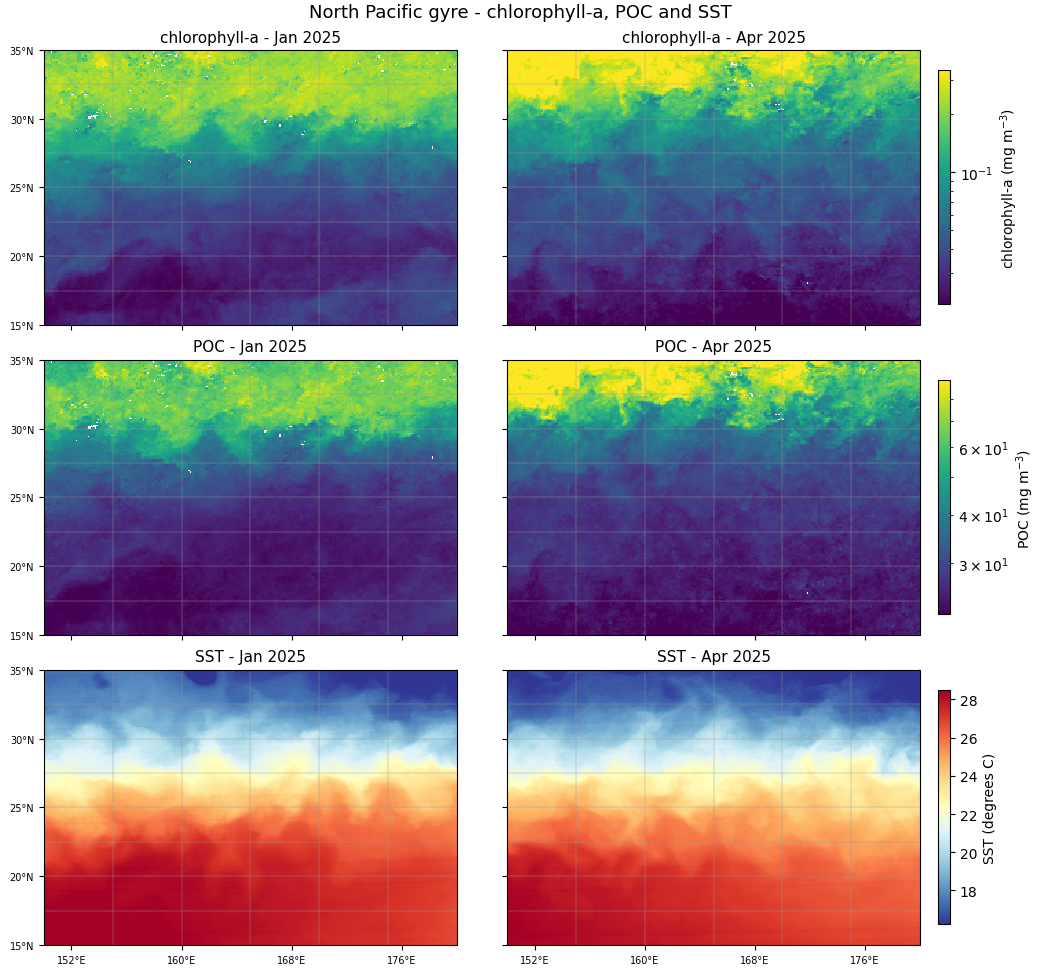

region                month       chlorophyll-a       POC       SST
                                        mg m^-3   mg m^-3      degC
South China Sea       Jan 2025            0.282      81.0     25.51
South China Sea       Apr 2025            0.121      46.8     28.61
  Apr 2025 minus Jan 2025: SST +3.10 degC, chlorophyll-a -57%, POC -42%
North Pacific gyre    Jan 2025            0.047      27.8     24.86
North Pacific gyre    Apr 2025            0.046      28.0     24.24
  Apr 2025 minus Jan 2025: SST -0.62 degC, chlorophyll-a -2%, POC +1%


In [17]:
# ── Try changing these ────────────────────────────────────────────────────
# Regions you can use here. Himawari sees 80°E to 160°W (200°E) only, so these are
# boxes that have SST as well as ocean colour. Copy a name exactly.
#
#   "Southeast Asia"    "South China Sea"    "Java Sea"
#   "Bay of Bengal"     "Coral Sea"          "North Pacific gyre"
#
COMPARE_REGIONS = ["South China Sea", "North Pacific gyre"]
MONTHS = ["202501", "202504"]        # two months, YYYYMM - both PACE and SST are read for these
# ─────────────────────────────────────────────────────────────────────────

if "SST_DIR" not in globals():
    raise RuntimeError("Run section 8 first. It downloads the SST files this "
                       "cell reads, and defines SST_DIR.")

import numpy as np
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm, Normalize

# variable key, short name, colour bar label, colour map, log scale?
ROWS = [("chlor_a", "chlorophyll-a", "chlorophyll-a (mg m$^{-3}$)", "viridis", True),
        ("poc", "POC", "POC (mg m$^{-3}$)", "viridis", True),
        ("sst", "SST", "SST (degrees C)", "RdYlBu_r", False)]


def month_name(month):
    """'202501' -> 'Jan 2025'."""
    return datetime.strptime(month, "%Y%m").strftime("%b %Y")


def sst_for(month, box):
    """SST in Celsius for one month, cut down to `box`.

    Reads the Himawari files that section 8 of this notebook downloaded into
    this module's own data/SST folder. These are large files, so crop first and
    convert to Celsius after, the same order section 4 of notebook 2.2 uses.
    """
    matches = [p for p in sorted(glob.glob(os.path.join(SST_DIR, "*.nc")))
               if f"_{month}01_" in os.path.basename(p)]
    if not matches:
        raise FileNotFoundError(
            f"No Himawari SST file for {month_name(month)} in {SST_DIR}.\n"
            f"  Add it to SST_PERIODS in section 8 and run that download again.")
    with xr.open_dataset(matches[0]) as d:
        da = select_region(d["sea_surface_temperature"].squeeze(drop=True), box).load()
    da = da - 273.15                      # Kelvin to Celsius
    da.attrs["units"] = "degrees_Celsius"
    return da

for month in MONTHS:
    if month not in by_month:
        raise KeyError(f"No PACE file for {month_name(month)}. Section 2 downloaded: "
                       + ", ".join(sorted(by_month)))
for region in COMPARE_REGIONS:
    if region not in REGIONS:
        raise KeyError(f"No region called {region!r}. Copy one of these exactly: "
                       + ", ".join(repr(name) for name in REGIONS))

medians = {}
for region in COMPARE_REGIONS:
    box = REGIONS[region]
    west, east, south, north = box
    if east <= 80 or west >= 180:
        raise ValueError(
            f"{region} is outside Himawari's view. These files cover 80E to 200E "
            "(160W), "
            "so pick a region inside that: 'Southeast Asia', 'South China Sea', "
            "'Java Sea', 'Bay of Bengal', 'Coral Sea' or 'North Pacific gyre'.")

    # Every panel of this region's figure, keyed by (variable, month).
    panel = {}
    for month in MONTHS:
        with xr.open_dataset(by_month[month]) as d:
            panel["chlor_a", month] = select_region(d["chlor_a"], box).load()
            panel["poc", month] = select_region(d["poc"], box).load()
        panel["sst", month] = sst_for(month, box)
        for key in ("chlor_a", "poc", "sst"):
            medians[region, month, key] = float(np.nanmedian(panel[key, month].values))

    if not np.isfinite(medians[region, MONTHS[0], "sst"]):
        raise ValueError(
            f"No SST pixels in {region}. Himawari sees 80E to 200E (160W) only, so "
            "pick a region inside that, such as 'South China Sea'.")

    # Match the panel shape to the box, or the map floats in white space.
    panel_w = 4.4
    panel_h = min(max(panel_w * (north - south) / (east - west), 2.4), 6.0)
    fig, axes = plt.subplots(len(ROWS), len(MONTHS),
                             figsize=(panel_w * len(MONTHS) + 1.6,
                                      panel_h * len(ROWS) + 0.9),
                             subplot_kw={"projection": ccrs.PlateCarree()},
                             squeeze=False, layout="constrained")
    for row, (key, name, label, cmap, is_log) in enumerate(ROWS):
        # One colour scale per row, fitted to both months together.
        stack = np.concatenate([panel[key, m].values.ravel() for m in MONTHS])
        stack = stack[np.isfinite(stack)]
        if is_log:
            stack = stack[stack > 0]
        lo, hi = np.percentile(stack, [2, 98])
        norm = LogNorm(vmin=lo, vmax=hi) if is_log else Normalize(vmin=lo, vmax=hi)

        for col, month in enumerate(MONTHS):
            ax = axes[row][col]
            da = panel[key, month]
            im = ax.pcolormesh(da.lon, da.lat, da, transform=ccrs.PlateCarree(),
                               norm=norm, cmap=cmap, shading="auto")
            # Without this the map quietly falls back to the whole world, and
            # your region ends up as a smear in one corner.
            ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
            ax.gridlines(linewidth=0.3, color="0.6")

            # Real ticks, not gridline labels: the layout leaves room for these.
            ticks = lambda lo, hi: [t for t in MaxNLocator(nbins=4).tick_values(lo, hi)
                                    if lo <= t <= hi]        # noqa: E731
            ax.set_xticks(ticks(west, east), crs=ccrs.PlateCarree())
            ax.set_yticks(ticks(south, north), crs=ccrs.PlateCarree())
            ax.xaxis.set_major_formatter(LongitudeFormatter())
            ax.yaxis.set_major_formatter(LatitudeFormatter())
            ax.tick_params(labelsize=7,
                           labelbottom=row == len(ROWS) - 1,   # outer panels
                           labelleft=col == 0)                 # only
            # Every panel says what it is and which month it is, because the
            # assignment asks you to label them.
            ax.set_title(f"{name} - {month_name(month)}", fontsize=11)
        fig.colorbar(im, ax=axes[row].tolist(), shrink=0.85, pad=0.02, label=label)

    fig.suptitle(f"{region} - chlorophyll-a, POC and SST", fontsize=13)
    save_fig(fig, f"chl_poc_sst_{slug(region)}_{'_'.join(MONTHS)}")
    plt.show()

# The same figures as numbers, for your assignment.
print(f"{'region':22s}{'month':10s}{'chlorophyll-a':>15s}{'POC':>10s}"
      f"{'SST':>10s}")
print(f"{'':22s}{'':10s}{'mg m^-3':>15s}{'mg m^-3':>10s}{'degC':>10s}")
for region in COMPARE_REGIONS:
    for month in MONTHS:
        chl = medians[region, month, "chlor_a"]
        poc = medians[region, month, "poc"]
        sst = medians[region, month, "sst"]
        print(f"{region:22s}{month_name(month):10s}{chl:15.3f}{poc:10.1f}"
              f"{sst:10.2f}")
    if len(MONTHS) == 2:
        first, second = MONTHS
        change = lambda key: (100 * (medians[region, second, key]      # noqa: E731
                                     - medians[region, first, key])
                              / medians[region, first, key])
        d_sst = medians[region, second, "sst"] - medians[region, first, "sst"]
        print(f"  {month_name(second)} minus {month_name(first)}: "
              f"SST {d_sst:+.2f} degC, "
              f"chlorophyll-a {change('chlor_a'):+.0f}%, POC {change('poc'):+.0f}%")

> ### 📝 For your Word document (2.1 §9 — required)
>
> Paste both figures into question 2 of the answer template, from `output/figures/`: `chl_poc_sst_south_china_sea_202501_202504.png` and `chl_poc_sst_north_pacific_gyre_202501_202504.png`. Caption each one `2.1 — ` followed by its filename.
>
> Take the numbers you need out of the printed table and put each one inside the sentence that uses it. Questions 2 and 3 say which ones.
>
> [Assignment questions 2 and 3](https://github.com/earthobservatory/eyes-on-earth-tutorials-public/blob/main/2.0_Tutorial_2_Overview_and_Assignment/README.md#part-b--analyse-the-ocean) in the handout list exactly what to write.